In [2]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
query = """
SELECT *
FROM features.customer_features
"""

customer_df = pd.read_sql(query, engine)

customer_df.shape

(206209, 14)

In [5]:
customer_df.head()

,user_id,total_orders,total_items,unique_products,avg_basket_size,avg_days_between_orders,std_days_between_orders,customer_tenure,reorder_rate,total_reorders,unique_departments,unique_aisles,favorite_hour,favorite_day
0,18,6,39,29,6.500000,6.466667,2.991175,6,0.256410,10,9,20,16,2
1,37,23,188,104,8.173913,12.687500,7.682936,23,0.446809,84,15,34,16,5
2,38,12,195,88,16.250000,22.878453,7.206990,12,0.548718,107,14,40,10,6
3,47,5,26,21,5.200000,9.750000,4.165965,5,0.192308,5,13,20,10,2
4,50,67,453,89,6.761194,5.691275,3.050912,67,0.803532,364,11,38,10,1


In [6]:
customer_df.isnull().sum()

user_id                    0
total_orders               0
total_items                0
unique_products            0
avg_basket_size            0
avg_days_between_orders    0
std_days_between_orders    0
customer_tenure            0
reorder_rate               0
total_reorders             0
unique_departments         0
unique_aisles              0
favorite_hour              0
favorite_day               0
dtype: int64

In [7]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,206209.0,103105.000000,59527.555167,1.0,51553.000000,103105.000000,154657.000000,206209.000000
total_orders,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
total_items,206209.0,157.289396,204.208233,3.0,39.000000,83.000000,188.000000,3725.000000
unique_products,206209.0,64.536238,56.592339,1.0,25.000000,48.000000,86.000000,726.000000
avg_basket_size,206209.0,9.951586,5.863570,1.0,5.740741,8.933333,13.000000,70.250000
avg_days_between_orders,206209.0,15.469670,7.207436,0.0,9.553797,14.692308,20.724409,30.000000
std_days_between_orders,206209.0,6.616467,3.268528,0.0,4.231001,7.033376,9.037772,21.213203
customer_tenure,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
reorder_rate,206209.0,0.432249,0.212144,0.0,0.267857,0.428571,0.595745,0.989529
total_reorders,206209.0,92.753158,158.400413,0.0,10.000000,33.000000,101.000000,3275.000000


<Axes: >

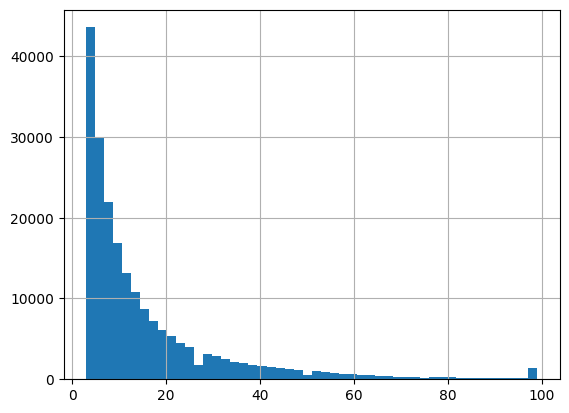

In [8]:
customer_df["total_orders"].hist(bins=50)

<Axes: >

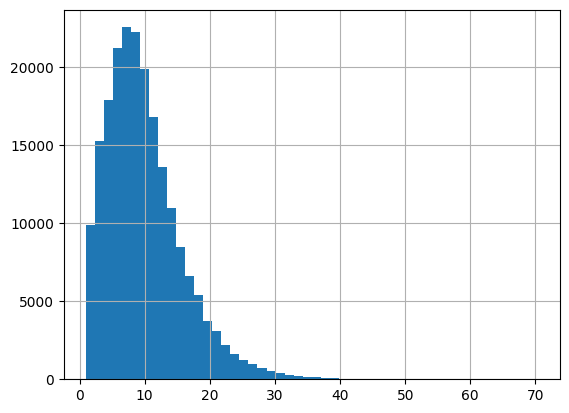

In [ ]:
customer_df["avg_basket_size"].hist(bins=50)

<Axes: >

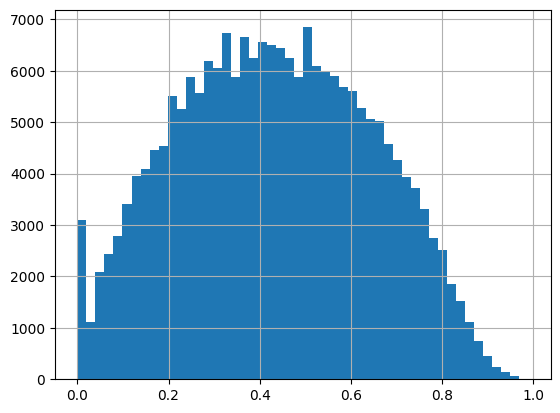

In [10]:
customer_df["reorder_rate"].hist(bins=50)

<Axes: >

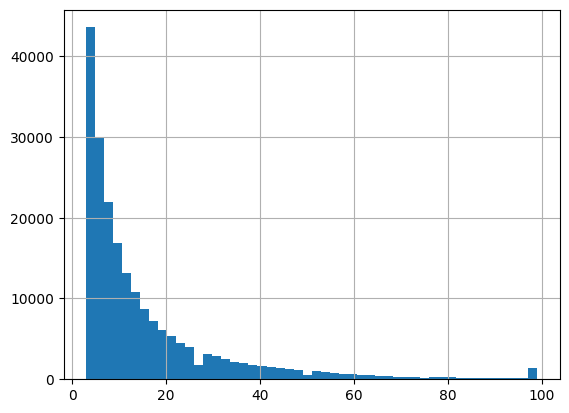

In [12]:
customer_df["customer_tenure"].hist(bins=50)

In [11]:
customer_df[
    [
        "total_orders",
        "avg_basket_size",
        "reorder_rate",
        "unique_products"
    ]
].corr()

,total_orders,avg_basket_size,reorder_rate,unique_products
total_orders,1.000000,0.021919,0.636891,0.670323
avg_basket_size,0.021919,1.000000,0.109718,0.534631
reorder_rate,0.636891,0.109718,1.000000,0.372337
unique_products,0.670323,0.534631,0.372337,1.000000
